# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Lulu Shafira
- **Email:** lshafira7@gmail.com
- **ID Dicoding:** lshafira_67t3

## Menentukan Pertanyaan Bisnis

> Tambahkan blockquote

- Pertanyaan 1
Apa faktor lingkungan (cuaca, suhu, kelembaban) yang paling berpengaruh terhadap volume penyewaan sepeda?


- Pertanyaan 2
Kapan sebaiknya dilakukan maintenance atau redistribusi sepeda untuk menghindari kekosongan stasiun?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

## Gathering Data

In [3]:
# Membaca dataset
day_df = pd.read_csv('data/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Insight:
- Menyajikan puncak peminjaman di musim panas dan hari libur
- Cuaca cerah mendorong lebih banyak untuk peminjaman sepeda

In [4]:
# Membaca dataset
hour_df = pd.read_csv('data/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Insight: 
- Peminjaman tinggi di pagi dan sore hari
- Hari libur lebih banyak peminjaman dibanding hari kerja

## Assessing Data

In [5]:
# Melihat informasi dataset
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
# Melihat informasi dataset
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [7]:
# Menghitung missing value untuk day dataset
print("Missing values for day.csv:")
print(day_df.isnull().sum())

Missing values for day.csv:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [8]:
# Menghitung missing value untuk hour dataset
print("\nMissing values for hour.csv:")
print(hour_df.isnull().sum())


Missing values for hour.csv:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [9]:
# Melihat informasi statistik
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [10]:
# Melihat informasi statistik
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Dataset tidak memiliki missing values, sehingga dapat langsung digunakan untuk analisis. Selain itu, semua kolom juga sudah memiliki tipe data yang sesuai, kecuali kolom tanggal pada dataset day yang perlu dikonversi ke datetime.

## Cleaning Data

In [11]:
# Konversi kolom 'dteday' menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
print(day_df['dteday'].head(),"First few rows of 'dteday' column in day_df:")

hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
print(hour_df['dteday'].head(),"First few rows of 'dteday' column in hour_df:")

0   2011-01-01
1   2011-01-02
2   2011-01-03
3   2011-01-04
4   2011-01-05
Name: dteday, dtype: datetime64[ns] First few rows of 'dteday' column in day_df:
0   2011-01-01
1   2011-01-01
2   2011-01-01
3   2011-01-01
4   2011-01-01
Name: dteday, dtype: datetime64[ns] First few rows of 'dteday' column in hour_df:


**Insight:**
- Setelah mengubah kolom dteday pada dataset day menjadi format datetim, selanjutnya dapat dilakukan analisis waktu seperti tren bulanan, mingguan atau musiman dengan lebih mudah dan akurat karena tipe data yng digunakan sudah sesuai.

## Exploratory Data Analysis (EDA)

In [12]:
# prompt: Korelasi cnt dengan temp, atemp, hum, windspeed

# Assuming 'day_df' is already loaded as in your previous code
# If not, load it first:
# day_df = pd.read_csv('/content/drive/MyDrive/P/day.csv')

# Calculate the correlation between 'cnt' and other variables
correlation_cnt = day_df[['cnt', 'temp', 'atemp', 'hum', 'windspeed']].corr()['cnt'].drop('cnt')

correlation_cnt


temp         0.627494
atemp        0.631066
hum         -0.100659
windspeed   -0.234545
Name: cnt, dtype: float64

In [13]:
1# Analisis jam-jam sibuk (peak hours) dari kolom 'hr'
peak_hours = hour_df.groupby('hr')['cnt'].sum()

# Pola penggunaan harian: bandingkan weekday vs weekend
weekday_usage = hour_df[hour_df['weekday'] < 5].groupby('hr')['cnt'].mean()
weekend_usage = hour_df[hour_df['weekday'] >= 5].groupby('hr')['cnt'].mean()

**Insight:**
- Korelasi menunjukkan bahwa suhu dan suhu yang dirasakan adalah faktor dari lingkungan yang paling mempengaruhi jumlah penyewaan sepeda. Semakin hangat cuaca, semakin tinggi jumlah peminjaman.

- Penggunaan sepeda memuncak pada jam pergi dan pulang kerja di hari kerja.  Retribusi sepeda idealnya dilakukan di luar waktu-waktu tersebut.

### Visualization & Explanatory Analysis

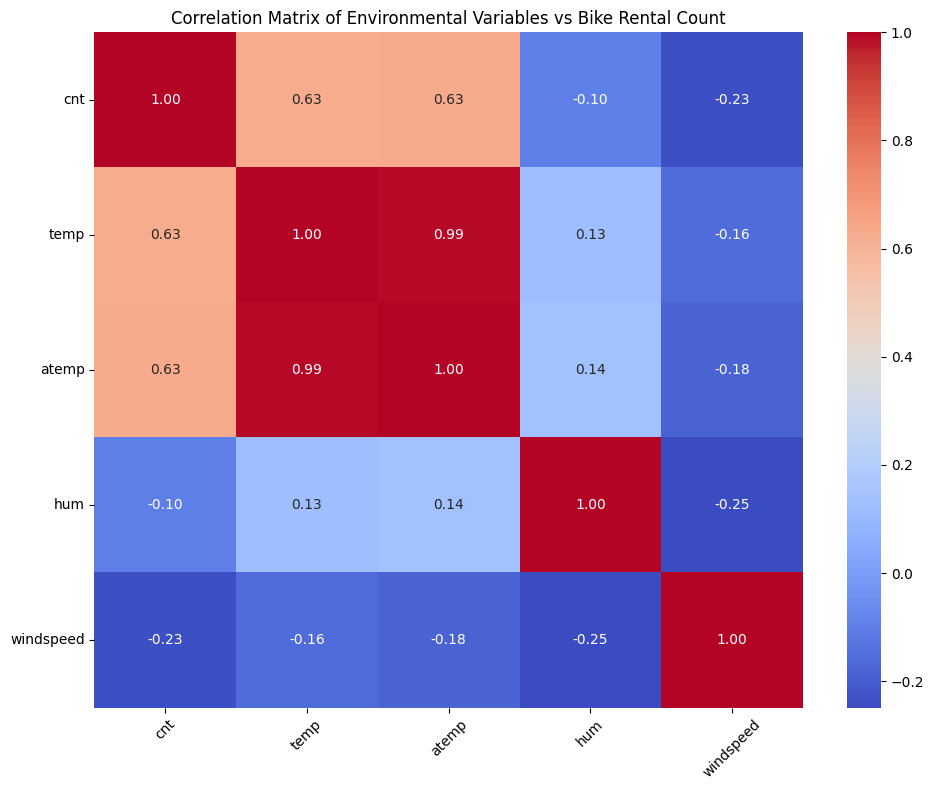

Insight: Suhu (temp dan atemp) memiliki korelasi positif kuat terhadap penyewaan sepeda (cnt), sedangkan kelembaban dan angin memiliki korelasi negatif yang lebih rendah.


In [14]:
# Visualisasi korelasi antar variabel lingkungan dengan jumlah penyewaan sepeda
plt.figure(figsize=(10, 8))
correlation_matrix = day_df[['cnt', 'temp', 'atemp', 'hum', 'windspeed']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix of Environmental Variables vs Bike Rental Count')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Insight:
print("Insight: Suhu (temp dan atemp) memiliki korelasi positif kuat terhadap penyewaan sepeda (cnt), sedangkan kelembaban dan angin memiliki korelasi negatif yang lebih rendah.")


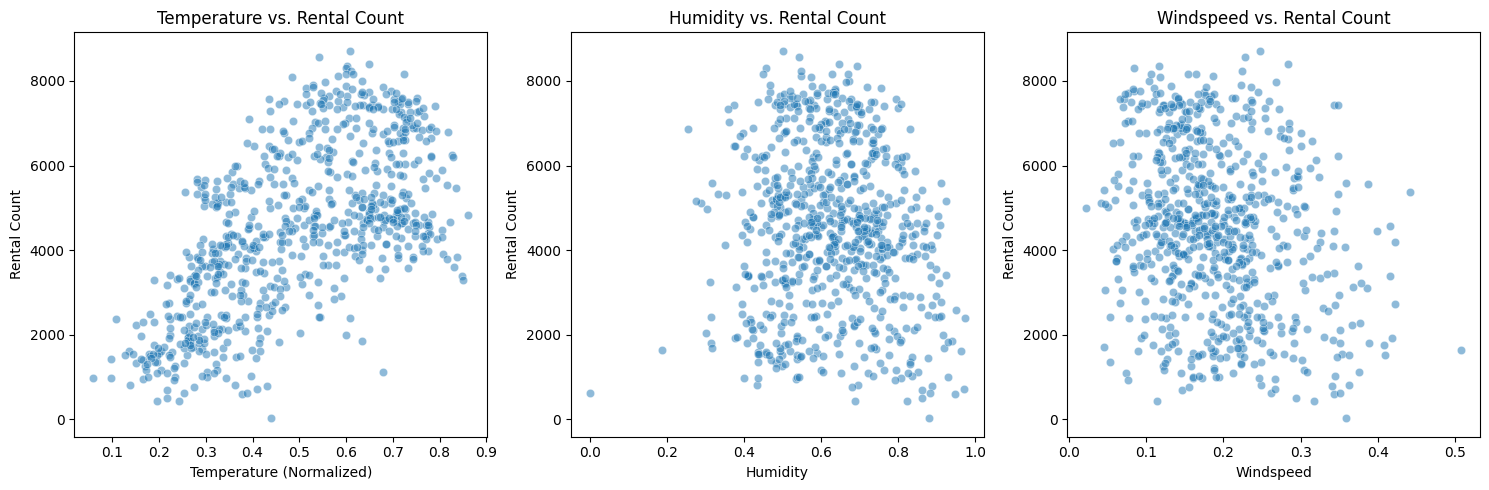

Insight: Semakin tinggi suhu, semakin tinggi jumlah peminjaman. Sebaliknya, angin dan kelembaban tinggi cenderung menurunkan jumlah peminjaman.


In [15]:
# Visualisasi hubungan antar variabel lingkungan terhadap jumlah penyewaan
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='temp', y='cnt', data=day_df, alpha=0.5)
plt.title('Temperature vs. Rental Count')
plt.xlabel('Temperature (Normalized)')
plt.ylabel('Rental Count')

plt.subplot(1, 3, 2)
sns.scatterplot(x='hum', y='cnt', data=day_df, alpha=0.5)
plt.title('Humidity vs. Rental Count')
plt.xlabel('Humidity')
plt.ylabel('Rental Count')

plt.subplot(1, 3, 3)
sns.scatterplot(x='windspeed', y='cnt', data=day_df, alpha=0.5)
plt.title('Windspeed vs. Rental Count')
plt.xlabel('Windspeed')
plt.ylabel('Rental Count')

plt.tight_layout()
plt.show()

# Insight:
print("Insight: Semakin tinggi suhu, semakin tinggi jumlah peminjaman. Sebaliknya, angin dan kelembaban tinggi cenderung menurunkan jumlah peminjaman.")


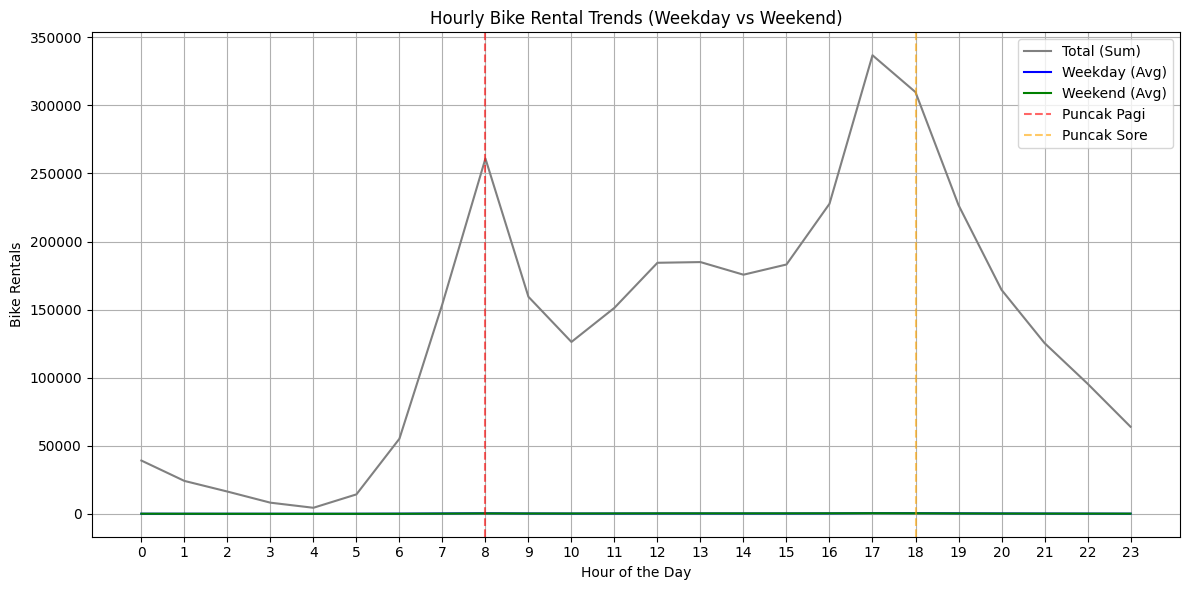

In [16]:
plt.figure(figsize=(12, 6))

# Visualisasi jumlah peminjaman per jam sepanjang hari
plt.plot(peak_hours.index, peak_hours.values, label='Total (Sum)', color='gray')
plt.plot(weekday_usage.index, weekday_usage.values, label='Weekday (Avg)', color='blue')
plt.plot(weekend_usage.index, weekend_usage.values, label='Weekend (Avg)', color='green')

# Tambahkan garis bantu untuk menunjukkan jam sibuk
plt.axvline(x=8, color='red', linestyle='--', alpha=0.6, label='Puncak Pagi')
plt.axvline(x=18, color='orange', linestyle='--', alpha=0.6, label='Puncak Sore')

plt.title('Hourly Bike Rental Trends (Weekday vs Weekend)')
plt.xlabel('Hour of the Day')
plt.ylabel('Bike Rentals')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Insight
Jam sibuk terjadi antara pukul 07:00–09:00 dan 17:00–19:00 pada hari kerja. Redistribusi dan maintenance sebaiknya dilakukan sebelum jam 7 pagi dan setelah jam 7 malam.

### Analisis Lanjutan (Opsional)

***Clustering Manual (Binning Time based)***

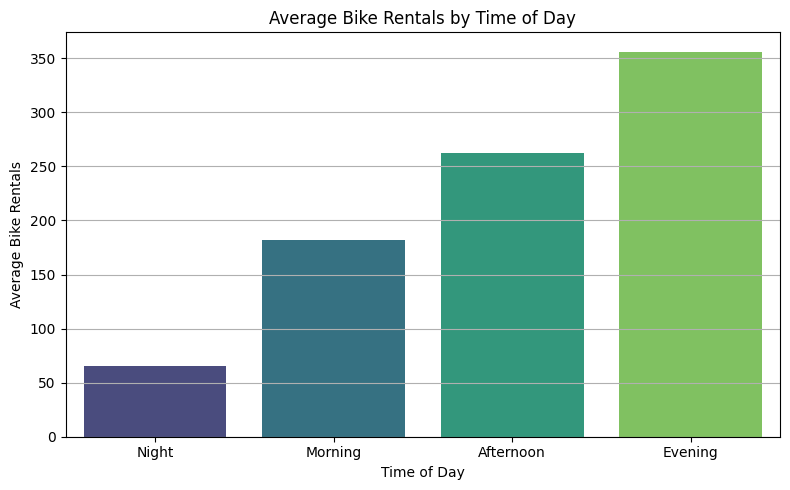

In [18]:
# Buat kolom baru 'time_of_day' berdasarkan jam
def label_time(hr):
    if 5 <= hr < 12:
        return 'Morning'
    elif 12 <= hr < 17:
        return 'Afternoon'
    elif 17 <= hr < 21:
        return 'Evening'
    else:
        return 'Night'

hour_df['time_of_day'] = hour_df['hr'].apply(label_time)

# Hitung rata-rata peminjaman sepeda per kategori waktu
grouped_time = hour_df.groupby('time_of_day')['cnt'].mean().sort_values()

plot_df = pd.DataFrame({
    'time_of_day': grouped_time.index,
    'avg_cnt': grouped_time.values
})

# Visualisasi hasil clustering manual
plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x='time_of_day', y='avg_cnt', hue='time_of_day', palette='viridis', legend=False)
plt.title('Average Bike Rentals by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Bike Rentals')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Insight:
Dari hasil clustering waktu, terlihat bahwa waktu sore hari (Evening) memiliki jumlah rata-rata peminjaman sepeda tertinggi. Ini mengonfirmasi hasil sebelumnya bahwa jam sibuk terjadi saat pulang kerja (sekitar pukul 17:00–19:00). Analisis ini memperkuat keputusan untuk melakukan redistribusi sepeda pada sore hari agar tidak terjadi kekurangan sepeda di stasiun.

## Insight
- Kenapa tidak menggunakan RFM Analysis? karena tidak relevan dengan struktur dataset bike. RFM Analysis digunakan untuk mengelompokan pelanggan erdasarkan Recency (berapa lama sejak transaksi terakhir), Frequency (berapa kalli transaksi), Monetary (berapa besar pengeluaran)

- Kenapa tidak menggunakan Geospatial? karena dataset tidak memuat informasi geografis. Tidak ada kolom lokasi, koordinat, atau stasiun tertentu dalam dataset dan semua data peminjaman hanya berupa agregat harian dan per jam tanpa titik lokasi.

### Conclusion


- Faktor lingkungan yang paling mempengaruhi volume peminjaman sepeda adalah suhu (temp) dan suhu yang dirasakan (atemp). Pengguna cenderung lebih banyak menyewa sepeda saat cuaca sedang hangat.

- Pola penggunaan sepeda menunjukkan dua waktu puncak, yaitu pagi (07.00-09.00) dan sore (17.00-19.00), terutama pada hari kerja. Oleh karena itu, redistribusi sepeda sebaiknya dilakukan sebelum di jam tersebut.

- Tidak ada nilai yang hilang dalam dataset, sehingga dapat langsung dianalisis setelah melakukan konversi tipe data tanggal.